In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [8]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
print("number of samples: ", df.shape[0], df.shape[1])
df.info()
df.describe()

number of samples:  20640 9
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


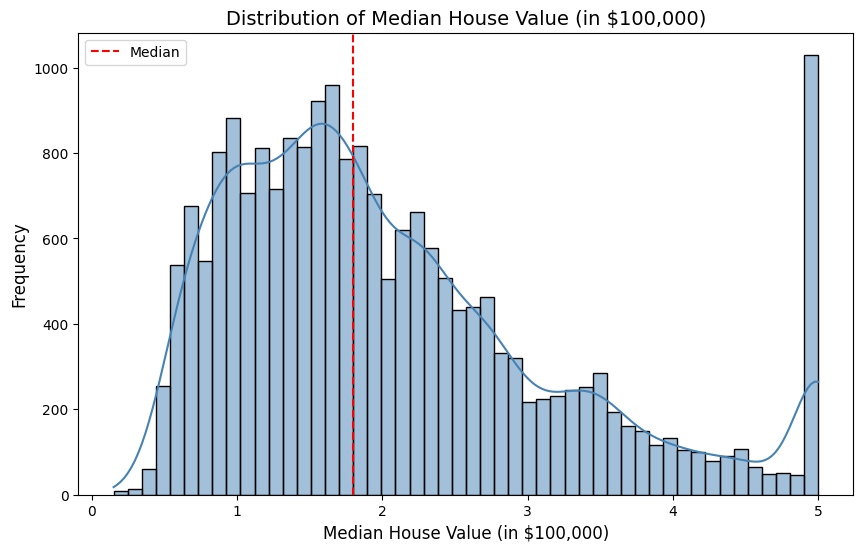

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["MedHouseVal"], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Median House Value (in $100,000)", fontsize=14)
plt.xlabel("Median House Value (in $100,000)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.axvline(df['MedHouseVal'].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.savefig('outputs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

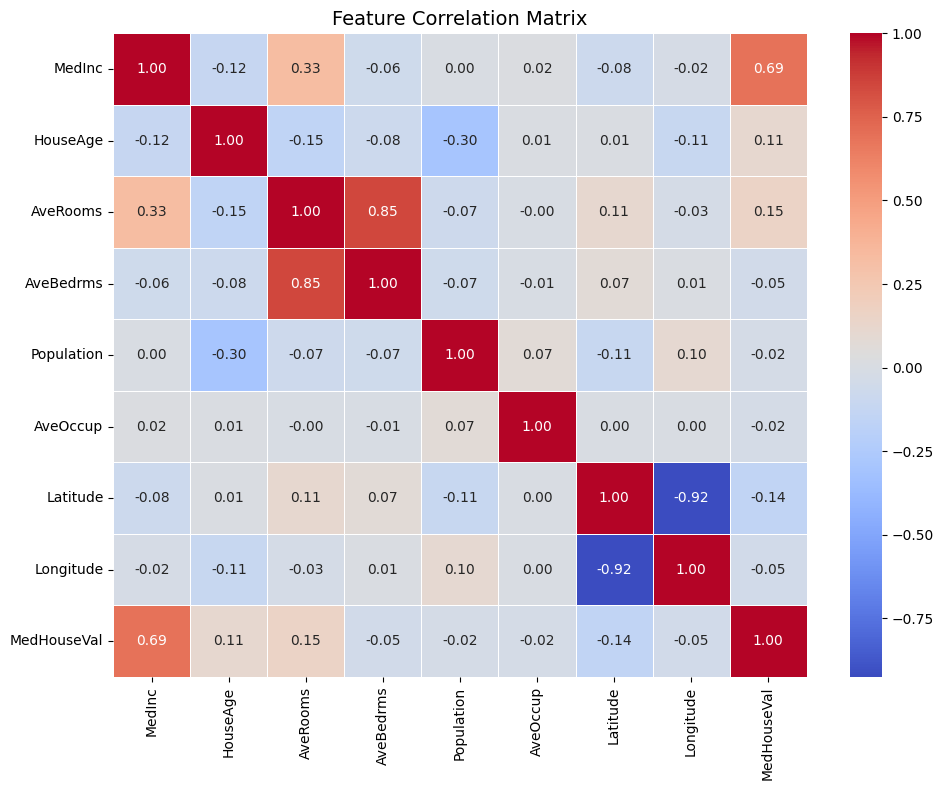

In [12]:
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

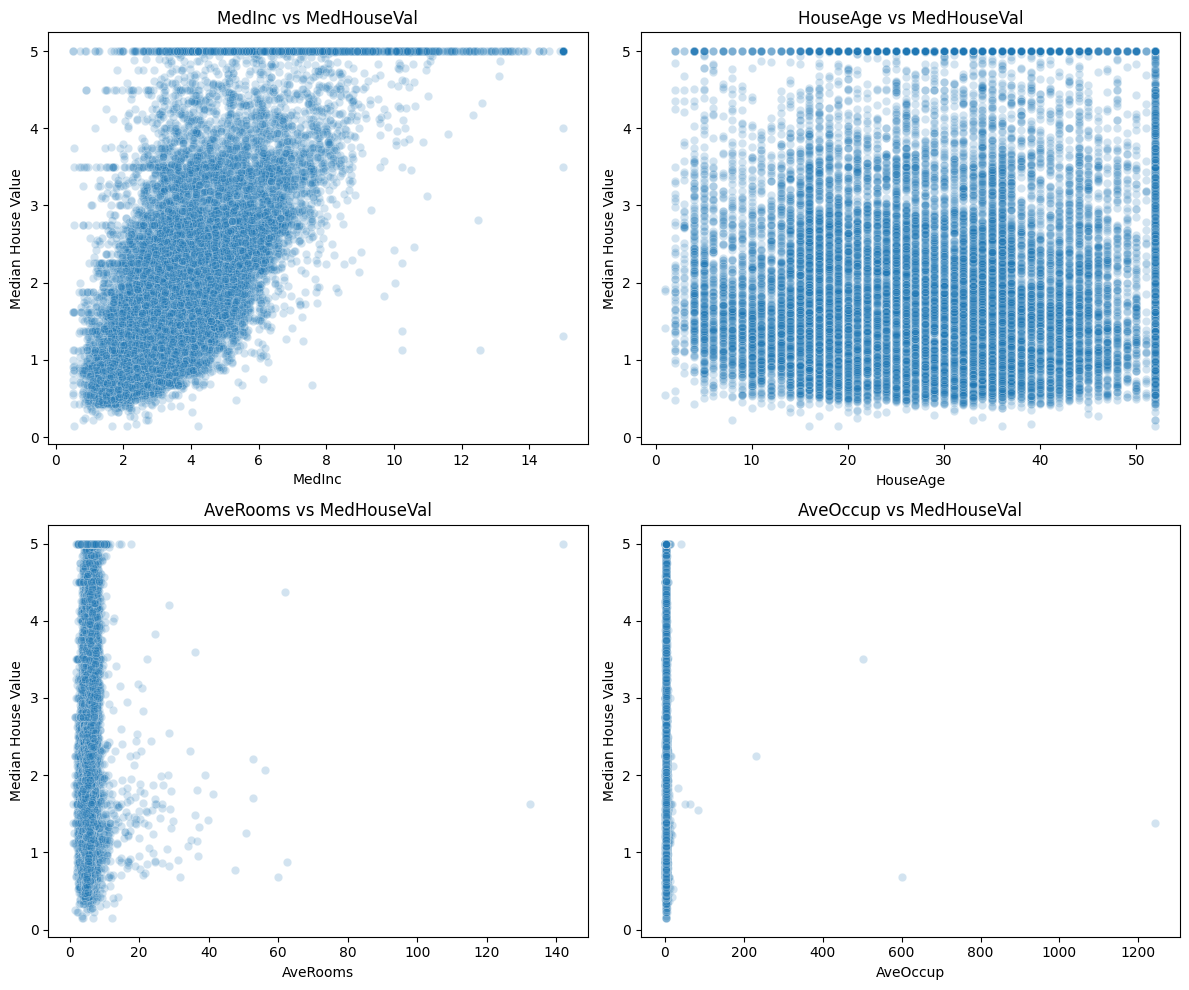

In [13]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(data=df, x=col, y='MedHouseVal', alpha=0.2, ax=axes[i])
    axes[i].set_title(f'{col} vs MedHouseVal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Median House Value')

plt.tight_layout()
plt.show()

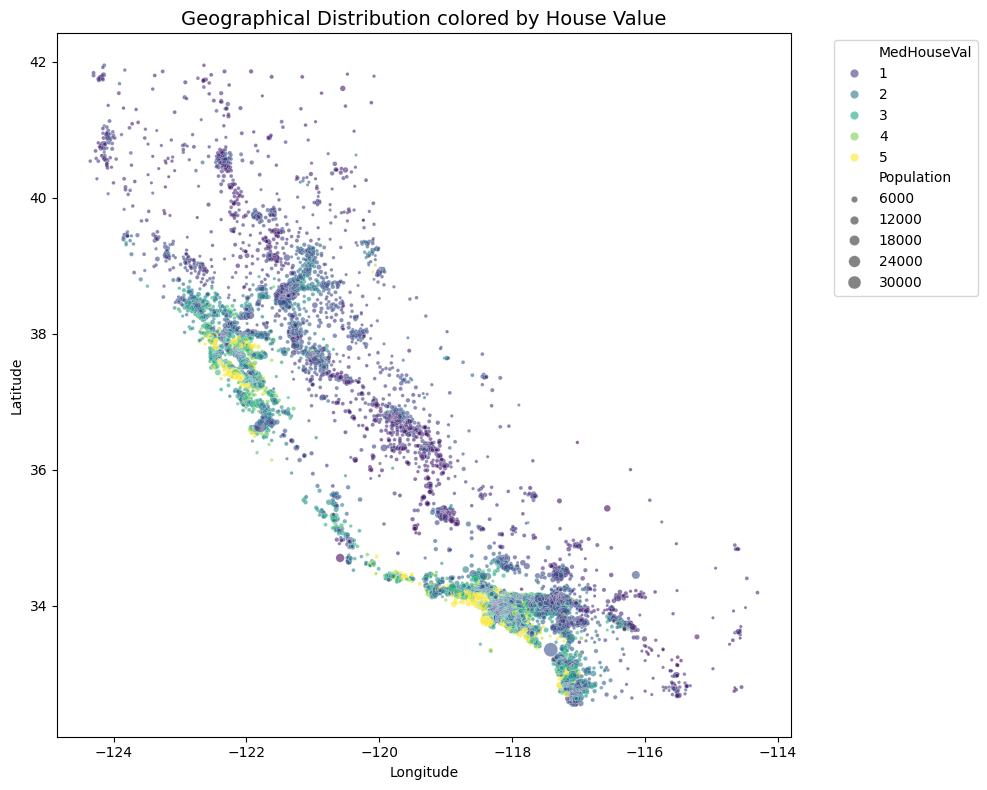

In [14]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='Longitude', y='Latitude', 
                hue='MedHouseVal', palette='viridis', 
                size='Population', sizes=(5,100), alpha=0.6)
plt.title('Geographical Distribution colored by House Value', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

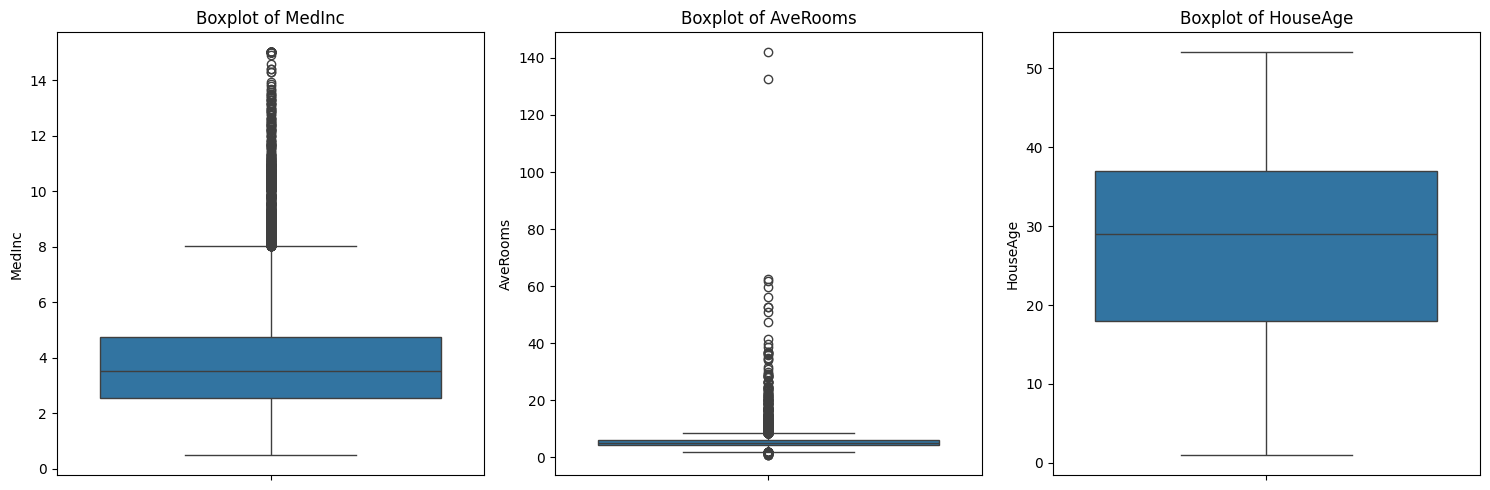

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
cols = ['MedInc', 'AveRooms', 'HouseAge']
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# feature_engineering

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()   

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df['Bedrms_per_Room'] = df['AveBedrms'] / df['AveRooms']
df['Rooms_per_Person'] = df['AveRooms'] / df['AveOccup']
df['Households'] = df['Population'] / df['AveOccup']
df['Old_House'] = (df['HouseAge'] > 50).astype(int)
df[['AveRooms', 'AveBedrms', 'Bedrms_per_Room', 'AveOccup', 'Rooms_per_Person', 'Households', 'Old_House']].head()

,AveRooms,AveBedrms,Bedrms_per_Room,AveOccup,Rooms_per_Person,Households,Old_House
0,6.984127,1.023810,0.146591,2.555556,2.732919,126.0,0
1,6.238137,0.971880,0.155797,2.109842,2.956685,1138.0,0
2,8.288136,1.073446,0.129516,2.802260,2.957661,177.0,1
3,5.817352,1.073059,0.184458,2.547945,2.283154,219.0,1
4,6.281853,1.081081,0.172096,2.181467,2.879646,259.0,1


In [5]:
def clip_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + factor * IQR
    lower_limit = Q1 - factor * IQR
    return series.clip(lower=lower_limit, upper=upper_limit)

cols_to_clip=['AveRooms','AveBedrms','AveOccup','Population']
for col in cols_to_clip:
    df[col]=clip_outliers(df[col])
    
print(df['AveRooms'].max())

8.469878027106942


In [7]:
X= df.drop('MedHouseVal', axis=1)
y= df['MedHouseVal']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   
    random_state=42   
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 16512
Test samples: 4128


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [21]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression R²: {r2_lr:.4f}")      

Linear Regression RMSE: 0.6699
Linear Regression R²: 0.6576


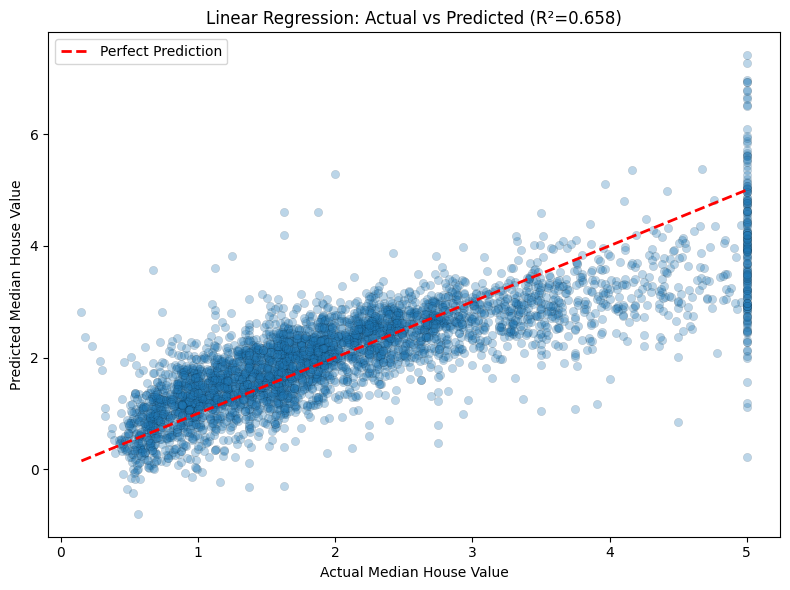

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, edgecolors='k', linewidth=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title(f'Linear Regression: Actual vs Predicted (R²={r2_lr:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coeff_df)

              Feature  Coefficient
6            Latitude    -0.923448
7           Longitude    -0.844968
0              MedInc     0.791699
5            AveOccup    -0.252195
1            HouseAge     0.127811
12    Bedrms_per_Room     0.083707
8   Bedrooms_per_room     0.083707
9    Rooms_per_Person     0.061779
4          Population     0.050721
3           AveBedrms     0.049632
11          Old_House     0.045311
2            AveRooms     0.032218
10         Households     0.005953


In [24]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree (max_depth=10):")
print(f"RMSE: {rmse_dt:.4f}  (≈ {rmse_dt*100000:.0f} Error in $)")
print(f"R²  : {r2_dt:.4f}")

Decision Tree (max_depth=10):
RMSE: 0.6418  (≈ 64181 Error in $)
R²  : 0.6857


In [25]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor:")
print(f"RMSE: {rmse_xgb:.4f}  (≈ {rmse_xgb*100000:.0f} Error in $)")
print(f"R²  : {r2_xgb:.4f}")

XGBoost Regressor:
RMSE: 0.4595  (≈ 45947 Error in $)
R²  : 0.8389


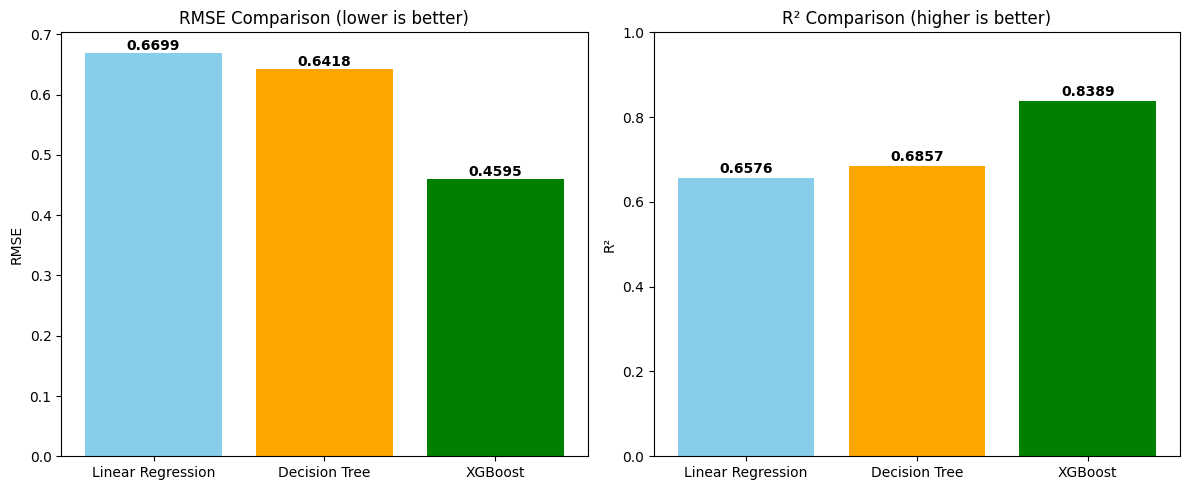

In [27]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Decision Tree', 'XGBoost']
rmse_scores = [rmse_lr, rmse_dt, rmse_xgb]
r2_scores = [r2_lr, r2_dt, r2_xgb]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

#  RMSE
bars1 = ax1.bar(models, rmse_scores, color=['skyblue', 'orange', 'green'])
ax1.set_title('RMSE Comparison (lower is better)')
ax1.set_ylabel('RMSE')
# number on top of bars
for bar, val in zip(bars1, rmse_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontweight='bold')

#  R²
bars2 = ax2.bar(models, r2_scores, color=['skyblue', 'orange', 'green'])
ax2.set_title('R² Comparison (higher is better)')
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, r2_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

              Feature  Importance
0              MedInc    0.440638
5            AveOccup    0.157700
7           Longitude    0.093830
6            Latitude    0.080938
1            HouseAge    0.057153
9    Rooms_per_Person    0.051556
8   Bedrooms_per_room    0.034483
2            AveRooms    0.028685
10         Households    0.020502
3           AveBedrms    0.018425
4          Population    0.016090
11          Old_House    0.000000
12    Bedrms_per_Room    0.000000


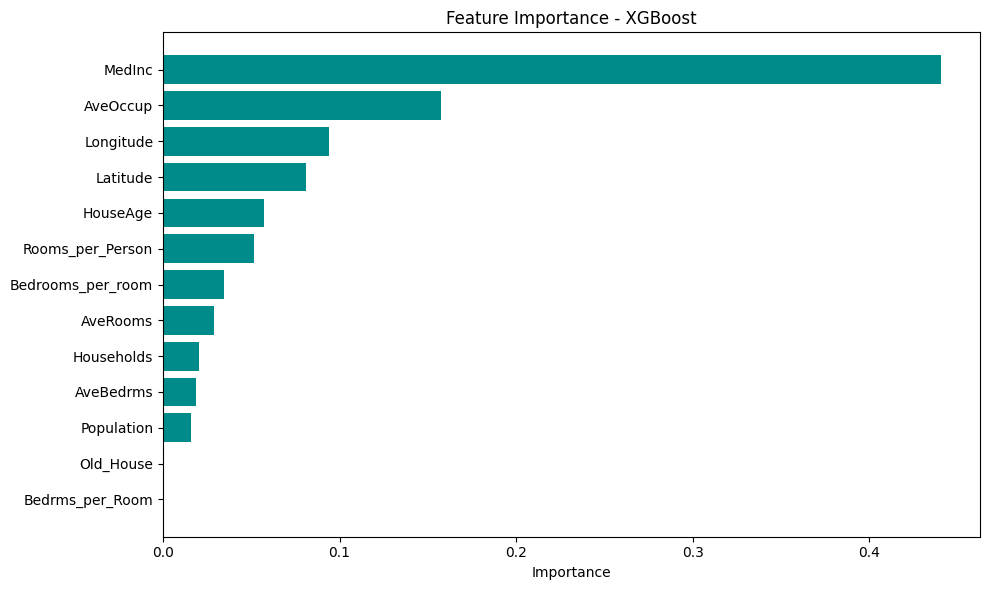

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkcyan')
plt.xlabel('Importance')
plt.title('Feature Importance - XGBoost')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()